In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Xandre Arsoler"
student_id = "TUPM-25-0260"

id_num = int(student_id[-3:])  # 260

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

print(f"Color 1: {color1}")
print(f"Color 2: {color2}")

# Load dataset here so df is ready for Cell 2
df = pd.read_csv('spotify_top_1000_tracks.csv')


Color 1: #1c0c14
Color 2: #082410


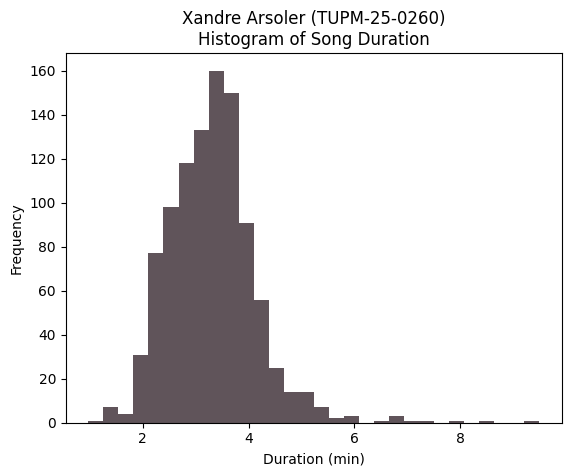

In [6]:
# --- Cell 2: Histogram of Song Duration ---
import matplotlib.pyplot as plt

df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)

plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()



C:\Users\admin\AppData\Local\Temp\ipykernel_25236\2658238145.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


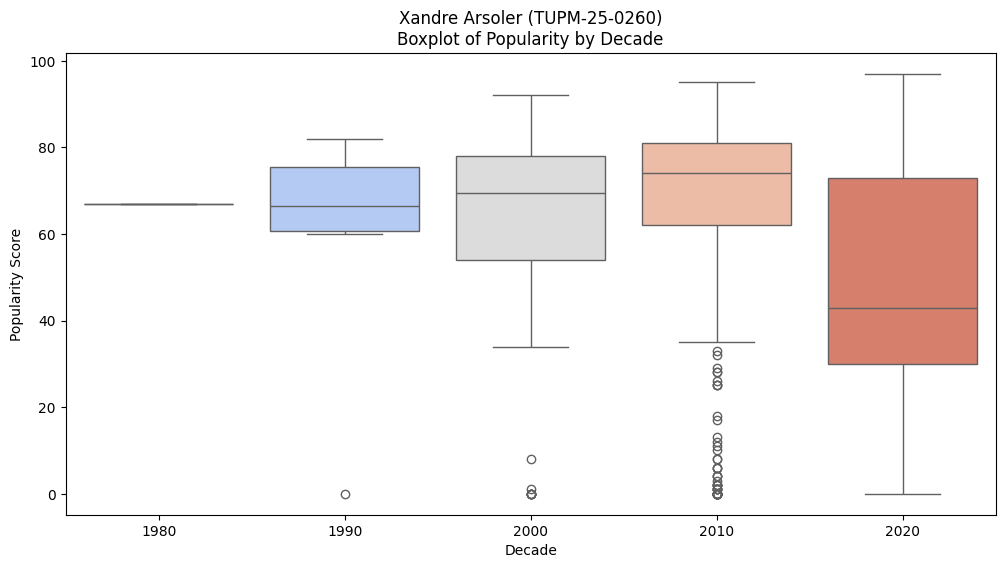

In [7]:
df = pd.read_csv('spotify_top_1000_tracks.csv')

student_name = "Xandre Arsoler"
student_id = "TUPM-25-0260"

df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.dropna(subset=['year'])
df['decade'] = (df['year'].astype(int) // 10) * 10

plt.figure(figsize=(12, 6))
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.xlabel("Decade")
plt.ylabel("Popularity Score")
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_25236\2699173092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


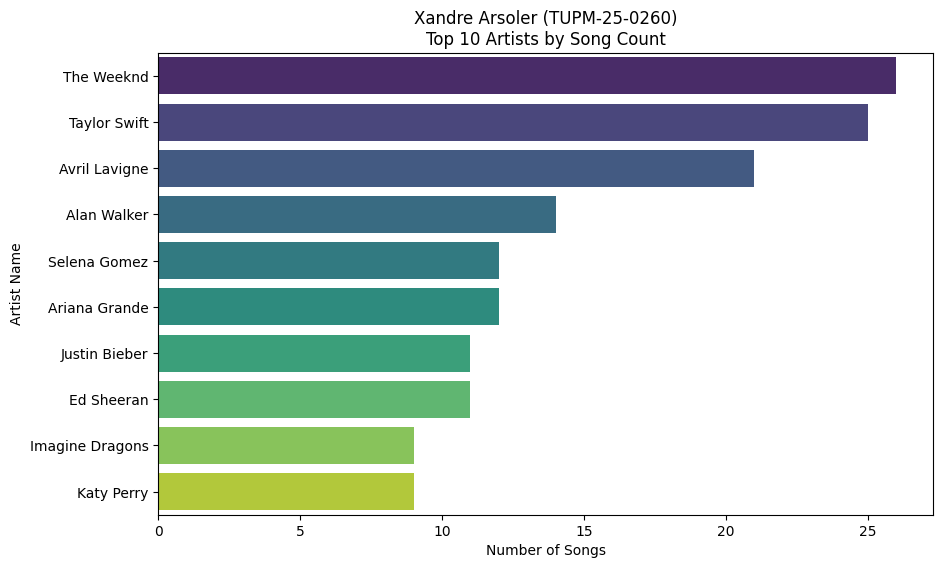

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(
    y='artist', 
    data=df,
    order=df['artist'].value_counts().head(10).index, 
    palette='viridis'
)
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.xlabel("Number of Songs")
plt.ylabel("Artist Name")
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_25236\451786710.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


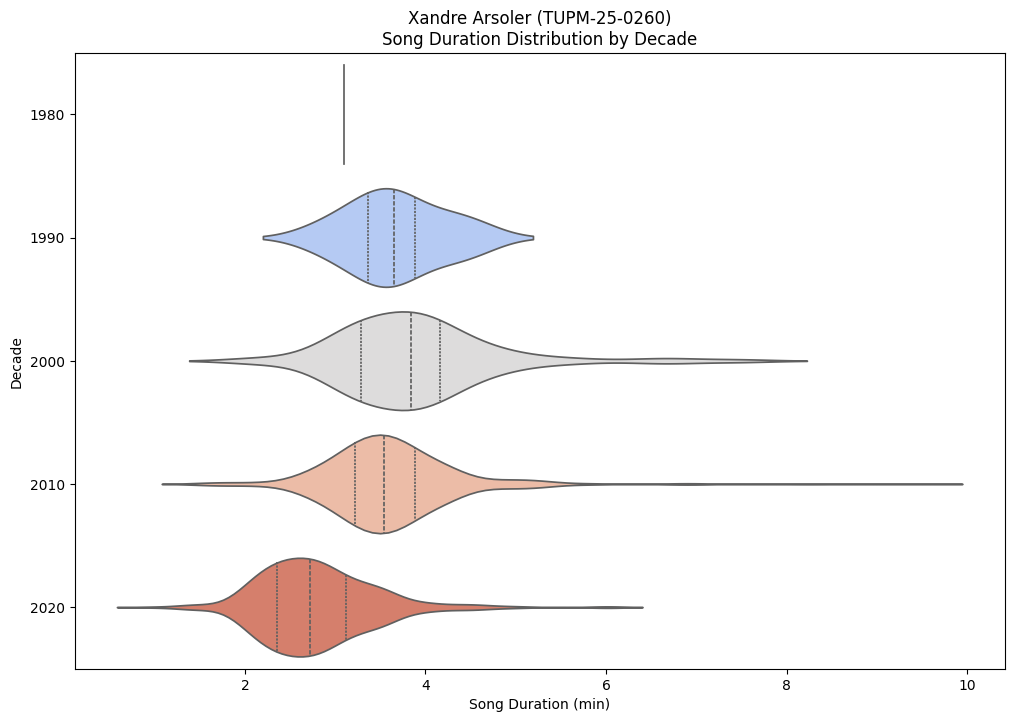

In [9]:
plt.figure(figsize=(12, 8))
sns.violinplot(
    data=df, 
    x='duration_min', 
    y='decade', 
    orient='h',            
    palette='coolwarm', 
    inner='quartile'
)
plt.title(f"{student_name} ({student_id})\nSong Duration Distribution by Decade")
plt.xlabel("Song Duration (min)")
plt.ylabel("Decade")
plt.show()


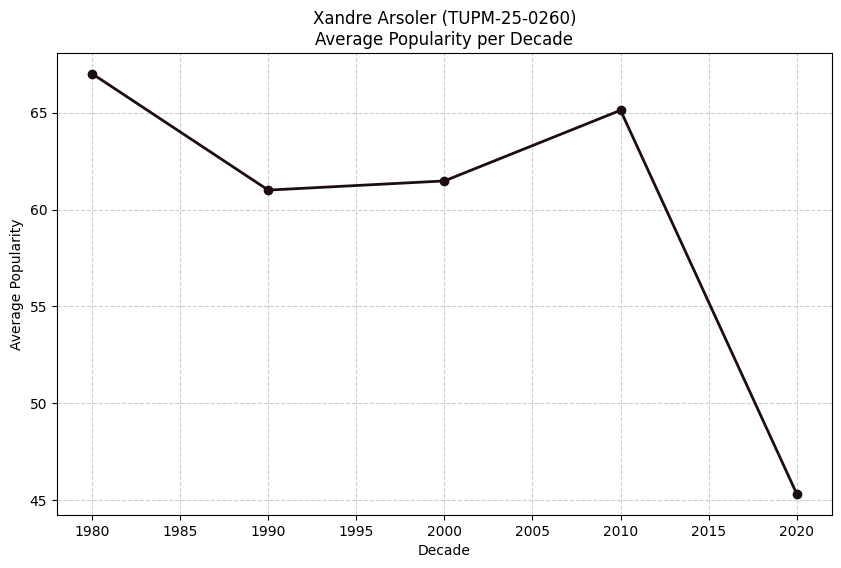

In [10]:
avg_pop = df.groupby('decade')['popularity'].mean()
plt.figure(figsize=(10, 6))
avg_pop.plot(kind='line', color=color1, marker='o', linewidth=2)
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


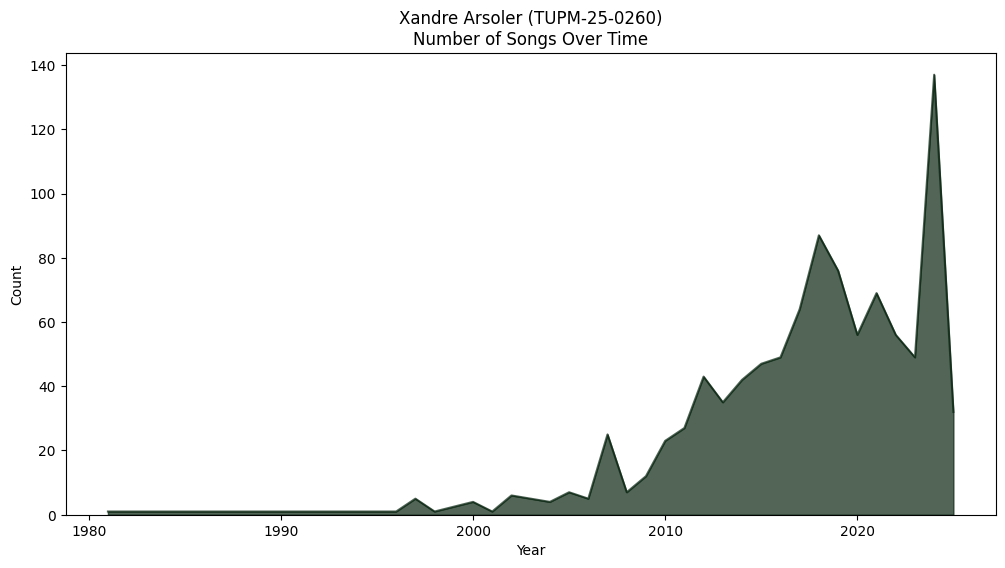

In [11]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
count_by_year = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()



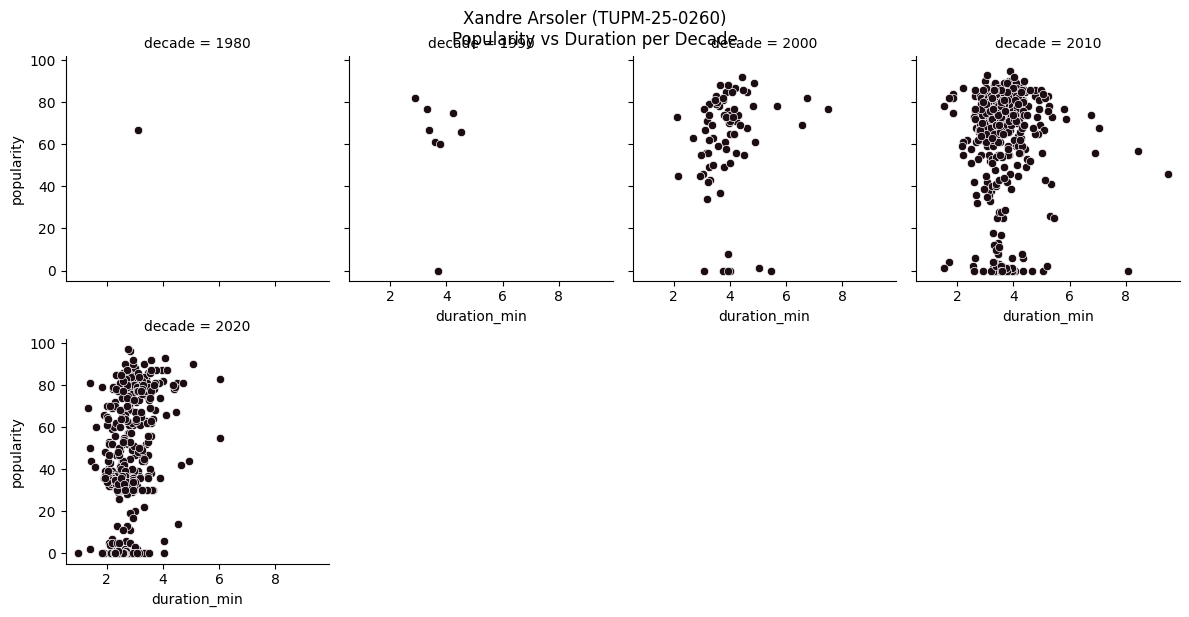

In [12]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color=color1)
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02)
plt.show()



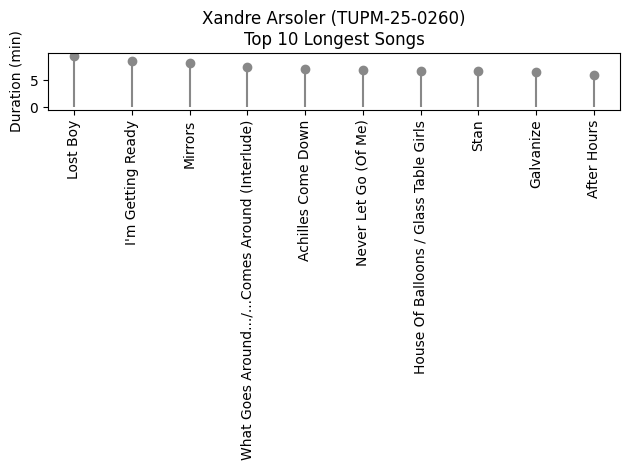

In [13]:
longest = df.nlargest(10, 'duration_min')
plt.stem(longest['track_name'], longest['duration_min'],
         linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()


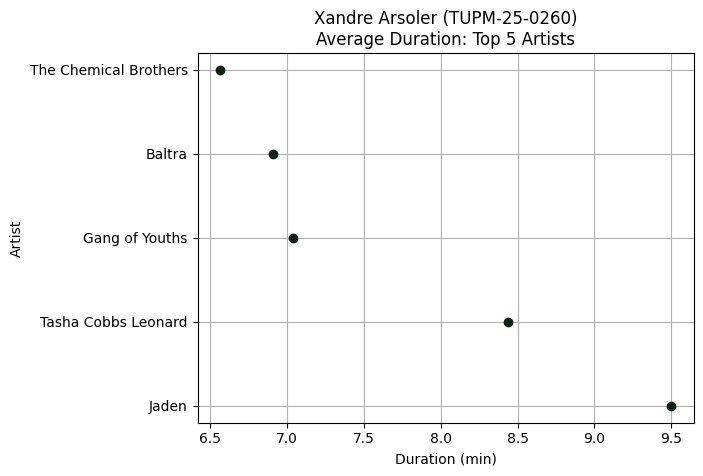

In [14]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.ylabel('Artist') 
plt.grid(True)
plt.show()


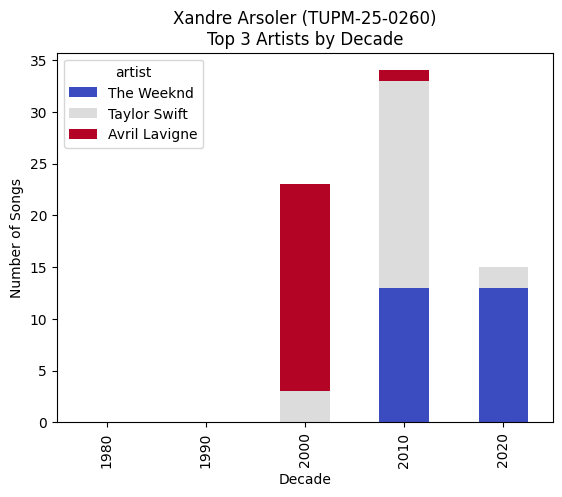

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

crosstab = pd.crosstab(df['decade'], df['artist'])
top3 = df['artist'].value_counts().head(3).index

crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.xlabel('Decade')
plt.show()


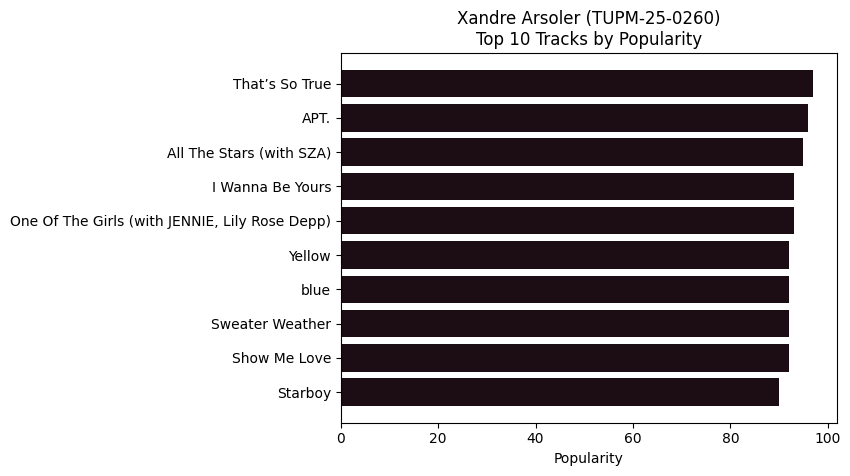

In [16]:
import matplotlib.pyplot as plt

top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()


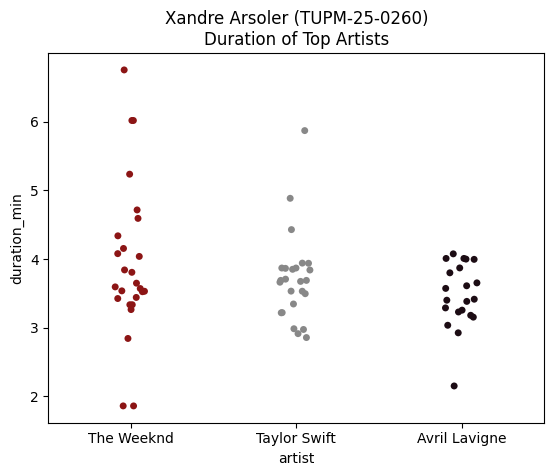

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

top_artists = df['artist'].value_counts().head(3).index
sns.stripplot(data=df[df['artist'].isin(top_artists)], 
              x='artist', y='duration_min', hue='artist', 
              palette=['#8C1515', '#888888', color1], legend=False)
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.show()


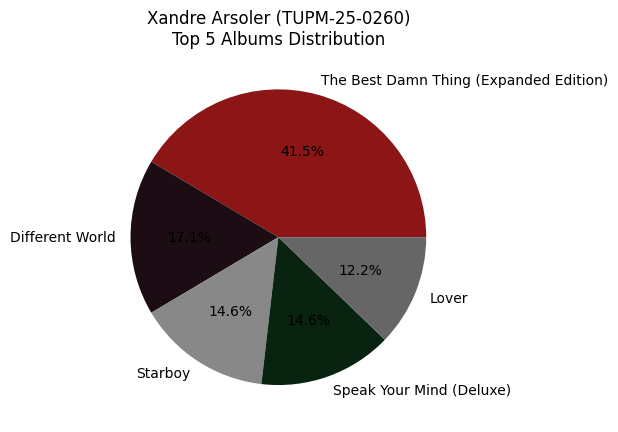

In [18]:
import matplotlib.pyplot as plt

top_albums = df['album'].value_counts().head(5)
colors = ['#8C1515', color1, '#888888', color2, '#666666']

plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors)
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()



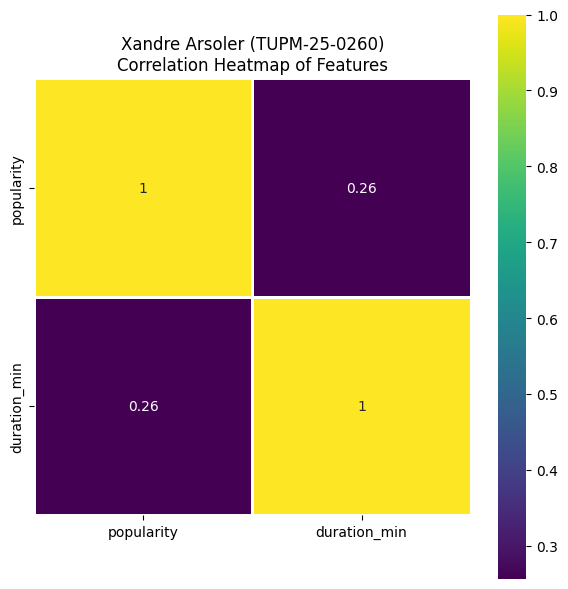

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('spotify_top_1000_tracks.csv')

student_name = "Xandre Arsoler"
student_id = "TUPM-25-0260"

# Select numerical columns
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()

# Correlation heatmap (no SciPy needed)
plt.figure(figsize=(6, 6))
sns.heatmap(
    df_numeric.corr(),
    annot=True,
    cmap='viridis',
    linewidths=.75,
    square=True
)

plt.title(f"{student_name} ({student_id})\nCorrelation Heatmap of Features")
plt.tight_layout()
plt.show()


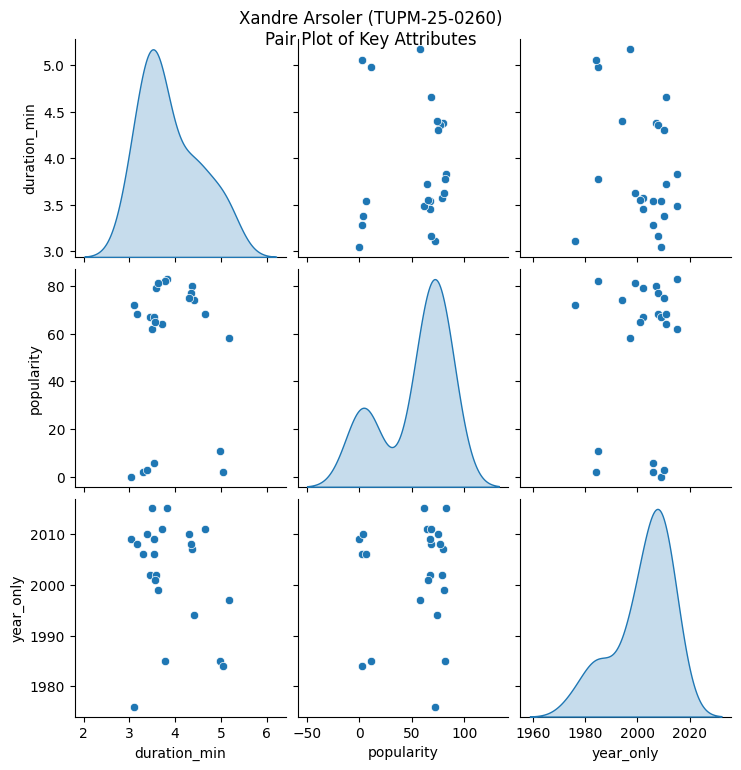

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('spotify_top_1000_tracks.csv')

student_name = "Xandre Arsoler"
student_id = "TUPM-25-0260"

# Convert release_date to numeric year
df['year_only'] = pd.to_numeric(df['release_date'], errors='coerce')

# Drop rows with missing values
df_clean = df.dropna(subset=['year_only', 'popularity', 'duration_min'])

# Pair plot of key attributes
sns.pairplot(df_clean[['duration_min', 'popularity', 'year_only']], diag_kind='kde')

plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02)
plt.show()


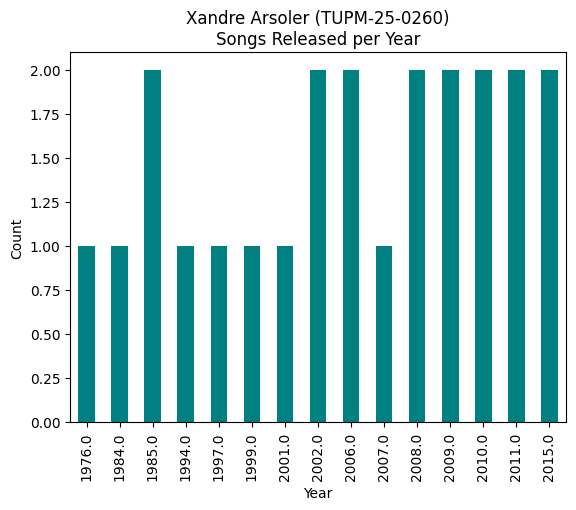

In [10]:
import matplotlib.pyplot as plt

color2 = 'teal'
df['release_year'] = pd.to_numeric(df['release_date'], errors='coerce')
df['release_year'].value_counts().sort_index().plot(kind='bar', color=color2)
plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')
plt.xlabel('Year')
plt.show()


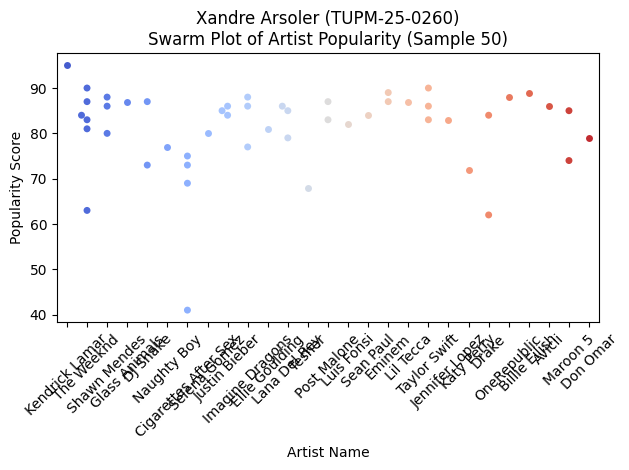

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.swarmplot(data=df.head(50), x='artist', y='popularity', hue='artist', palette='coolwarm', legend=False)
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=45) 
plt.ylabel('Popularity Score')
plt.xlabel('Artist Name')
plt.tight_layout() 
plt.show()


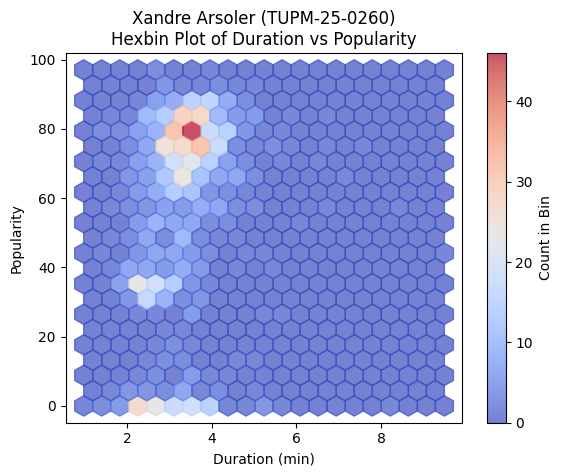

In [12]:
import matplotlib.pyplot as plt

plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, cmap='coolwarm', alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.colorbar(label='Count in Bin')
plt.show()


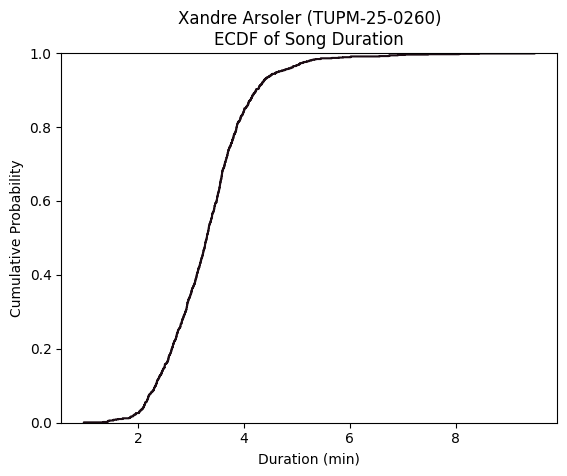

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('spotify_top_1000_tracks.csv')

student_name = "Xandre Arsoler"
student_id = "TUPM-25-0260"

# Recreate color1 from your student ID
id_num = int(student_id[-3:])  # 260
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"

# ECDF plot of song duration
sns.ecdfplot(data=df, x='duration_min', color=color1)
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.show()


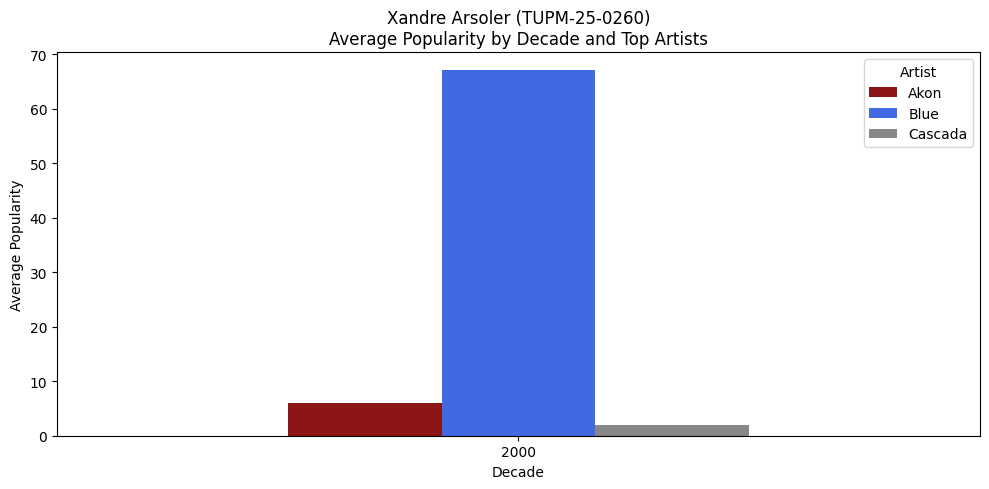

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

df['release_year'] = pd.to_numeric(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_year', 'popularity'])
df['decade'] = (df['release_year'] // 10).astype(int) * 10

top3 = df['artist'].value_counts().head(3).index
df_top3 = df[df['artist'].isin(top3)]
avg_artist_decade = df_top3.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)

if not avg_artist_decade.empty:
    avg_artist_decade.plot(kind='bar', figsize=(10, 5), color=['#8C1515', 'royalblue', '#888888'])
    plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
    plt.ylabel('Average Popularity')
    plt.xlabel('Decade')
    plt.legend(title='Artist')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Error: No numeric data available for the selected artists and decades.")
